# Cylinder Shape Detection — 단계별 시각화

`3d_cylinder_shape_detection.py`의 `fit_cylinder()` 함수가 **포인트 클라우드 + 임의의 3D 입력점**으로부터 어떻게 원기둥(파이프)을 검출하는지 단계별로 따라가며 시각화합니다.

## 전체 아이디어

원기둥 표면 위 한 점에서의 **법선(normal)은 항상 원기둥 축에 수직**입니다. 따라서:

1. 입력점 주변의 점들을 모으고 (KDTree)
2. 각 점의 법선을 추정한 뒤
3. 법선들의 **공분산**을 분석하면 → 법선이 가장 적게 분포하는 방향 = **원기둥 축**
4. 축에 수직인 2D 평면에 점들을 투영하면 → 원기둥 단면이 **원**으로 보임
5. 그 2D 원을 **RANSAC**으로 피팅하면 → 중심·반지름을 얻음
6. 2D 결과를 다시 3D로 복원 → 원기둥 축 origin / direction / radius

## 시각화 방식

- **3D 장면(0·1·2·3·6단계)** — open3d `draw_plotly`로 노트북 안에 **인터랙티브** 렌더링 (마우스로 회전·확대, 깊이 처리가 정확해 점/원기둥 구분이 잘 됨)
- **2D 단면(4·5단계)** — 본질적으로 평면 위 분석이라 matplotlib 2D 그래프가 더 명확

> 인터랙티브 plotly가 안 보이면 Jupyter에서 `pip install "plotly>=5"` 후 커널 재시작이 필요할 수 있습니다.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import open3d as o3d

%matplotlib inline

# 한글 폰트 설정 (그래프 안의 한글 깨짐 방지)
# 'Noto Sans CJK JP'는 한·중·일 통합 폰트라 한글도 정상 출력됨
_available = {f.name for f in fm.fontManager.ttflist}
for _name in ['NanumGothic', 'Noto Sans CJK KR', 'Noto Sans CJK JP',
              'Malgun Gothic', 'AppleGothic']:
    if _name in _available:
        plt.rcParams['font.family'] = _name
        print(f'한글 폰트 설정: {_name}')
        break
else:
    print('한글 폰트를 찾지 못했습니다. 그래프의 한글이 깨질 수 있습니다.')
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 부호 깨짐 방지

np.random.seed(42)  # 재현 가능하게 고정

# 알고리즘 파라미터 (원본 스크립트와 동일)
RADIUS_TRUE   = 0.1     # 합성 원기둥의 실제 반지름
HEIGHT_TRUE   = 0.4     # 합성 원기둥의 실제 높이
SEARCH_RADIUS = 0.2     # KDTree 이웃 탐색 반경
NORMAL_RADIUS = 0.05    # 법선 추정 반경
INLIER_THRESH = 0.005   # RANSAC 인라이어 거리 임계값
N_ITER        = 500     # RANSAC 반복 횟수

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
한글 폰트 설정: Noto Sans CJK JP


In [ ]:
# ============================================================
# open3d 인라인 시각화 헬퍼 (plotly 기반, 노트북 안에서 인터랙티브 렌더링)
#   draw_geometries는 별도 창을 띄우므로 draw_plotly로 노트북 안에 그림
# ============================================================
RGB = {
    'gray':   [0.70, 0.70, 0.70],
    'blue':   [0.25, 0.41, 0.88],
    'orange': [1.00, 0.55, 0.00],
    'green':  [0.10, 0.70, 0.20],
    'red':    [0.90, 0.10, 0.10],
}

def _ds(arr, n=20000):
    """표시용 다운샘플 (plotly가 무거워지지 않게)."""
    arr = np.asarray(arr)
    if len(arr) <= n:
        return arr
    return arr[np.random.choice(len(arr), n, replace=False)]

def make_pcd(points, color):
    p = o3d.geometry.PointCloud()
    p.points = o3d.utility.Vector3dVector(np.asarray(points, dtype=float))
    p.paint_uniform_color(RGB.get(color, color))
    return p

def make_marker(center, color, radius):
    s = o3d.geometry.TriangleMesh.create_sphere(radius=float(radius))
    s.translate(np.asarray(center, dtype=float))
    s.paint_uniform_color(RGB.get(color, color))
    s.compute_vertex_normals()
    return s

def make_lines(starts, ends, color):
    """starts→ends 선분들을 LineSet으로 (법선/축 화살표 대용)."""
    starts = np.atleast_2d(np.asarray(starts, dtype=float))
    ends   = np.atleast_2d(np.asarray(ends,   dtype=float))
    n = len(starts)
    ls = o3d.geometry.LineSet()
    ls.points = o3d.utility.Vector3dVector(np.vstack([starts, ends]))
    ls.lines  = o3d.utility.Vector2iVector([[i, i + n] for i in range(n)])
    ls.colors = o3d.utility.Vector3dVector(np.tile(RGB.get(color, color), (n, 1)))
    return ls

def make_cylinder(origin, direction, radius, height, color):
    """origin을 중심으로 direction을 축으로 하는 원기둥 메시."""
    cyl = o3d.geometry.TriangleMesh.create_cylinder(radius=float(radius), height=float(height))
    d = np.asarray(direction, dtype=float); d = d / np.linalg.norm(d)
    z = np.array([0, 0, 1.0])
    vc = np.cross(z, d); s = np.linalg.norm(vc); c = np.dot(z, d)
    if s > 1e-6:
        k = np.array([[0, -vc[2], vc[1]], [vc[2], 0, -vc[0]], [-vc[1], vc[0], 0]])
        R = np.eye(3) + k + k @ k * ((1 - c) / (s ** 2))
    else:
        R = np.eye(3) if c > 0 else -np.eye(3)
    cyl.rotate(R, center=(0, 0, 0))
    cyl.translate(np.asarray(origin, dtype=float))
    cyl.paint_uniform_color(RGB.get(color, color))
    cyl.compute_vertex_normals()
    return cyl

def show3d(geoms):
    """plotly로 노트북 안에 인터랙티브 렌더링 (마우스로 회전/확대 가능)."""
    o3d.visualization.draw_plotly(geoms, width=720, height=600)

## 0. 데이터 준비 — 합성 원기둥 또는 실제 PCD

아래 `USE_REAL_PCD` 스위치로 데이터 소스를 고릅니다.

- `False` (기본): Z축 원기둥(반지름 0.1, 높이 0.4)을 합성 — 알고리즘 이해용
- `True`: 실제 `.pcd`/`.ply` 파일 로드 — 현장 데이터 테스트용

**실제 PCD를 쓸 때 주의할 점:**
1. **단위(scale)** — PCD가 mm 단위면 `PCD_SCALE = 1e-3`으로 m 변환 (아래 파라미터들이 m 기준이라 중요)
2. **입력 포인트(`input_point`)** — 검출하려는 **파이프 표면 근처 한 점**을 직접 찍어줘야 함 (이 점 주변만 검출함)
3. **파라미터** — `SEARCH_RADIUS`, `NORMAL_RADIUS`, `INLIER_THRESH`를 파이프 굵기에 맞게 조정. 굵은 파이프면 더 크게.

In [ ]:
# ============================================================
# 데이터 소스 선택
# ============================================================
USE_REAL_PCD = True                       # True로 바꾸면 실제 파일 로드
PCD_PATH     = "../../sample/MERGED_SPOOL-004_0001_20260528T170812.pcd"                # 실제 PCD/PLY 경로
PCD_SCALE    = 1e-3                         # 단위 변환 (mm→m면 1e-3, 이미 m면 1.0)

# 실제 데이터일 때 검출하려는 파이프 표면 근처 좌표 (m 단위, scale 적용 후 기준)
# None이면 포인트 클라우드 중심을 자동으로 사용
REAL_INPUT_POINT = None
# ============================================================


def create_test_cylinder(n_points=5000, radius=RADIUS_TRUE, height=HEIGHT_TRUE):
    z = np.random.uniform(-height/2, height/2, n_points)
    theta = np.random.uniform(0, 2*np.pi, n_points)
    x = radius * np.cos(theta)
    y = radius * np.sin(theta)
    points = np.stack([x, y, z], axis=1)
    points += np.random.normal(0, 0.002, points.shape)  # 측정 노이즈
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)
    return pcd


if USE_REAL_PCD:
    pcd = o3d.io.read_point_cloud(PCD_PATH)
    pts = np.asarray(pcd.points) * PCD_SCALE
    if len(pts) == 0:
        raise ValueError(f"점을 불러오지 못했습니다: {PCD_PATH}")
    pcd.points = o3d.utility.Vector3dVector(pts)
    all_pts = pts
    # 입력점 결정: 지정값 없으면 클라우드 중심 사용
    input_point = (np.asarray(REAL_INPUT_POINT, dtype=float)
                   if REAL_INPUT_POINT is not None else all_pts.mean(axis=0))
    print(f"실제 PCD 로드: {PCD_PATH}")
    print(f"  점 개수 : {len(all_pts):,}  (scale={PCD_SCALE})")
    print(f"  범위    : {all_pts.min(axis=0).round(3)} ~ {all_pts.max(axis=0).round(3)} m")
    if REAL_INPUT_POINT is None:
        print("  [참고] input_point를 클라우드 중심으로 자동 설정했습니다.")
        print("         특정 파이프를 검출하려면 REAL_INPUT_POINT를 직접 지정하세요.")
else:
    pcd = create_test_cylinder()
    all_pts = np.asarray(pcd.points)
    # 합성 원기둥 표면 근처 한 점
    input_point = np.array([RADIUS_TRUE, 0.0, 0.0])
    print("합성 원기둥 사용")

print("input_point =", np.round(input_point, 4))

# 장면 크기 → 마커/화살표 크기 자동 스케일 (합성·실제 모두 적절히 보이게)
SCENE_DIAG = float(np.linalg.norm(all_pts.max(axis=0) - all_pts.min(axis=0)))
MARKER_R   = SCENE_DIAG * 0.012

# open3d 인라인 렌더링: 전체 점(회색) + 입력점(빨간 구)
show3d([
    make_pcd(_ds(all_pts), 'gray'),
    make_marker(input_point, 'red', MARKER_R),
])
print('0. 입력 데이터: 포인트 클라우드(회색) + 입력점(빨간 구)')

## 1. KDTree 이웃 탐색

```python
pcd_tree = o3d.geometry.KDTreeFlann(pcd)
[k, idx, _] = pcd_tree.search_radius_vector_3d(input_point, search_radius)
neighborhood = pcd.select_by_index(idx)
```

입력점 반경 `SEARCH_RADIUS` 안의 점들만 골라냅니다. 이후 모든 분석은 이 **국소 이웃(neighborhood)** 에 대해서만 수행됩니다 — 전체가 아니라 입력점 근처의 파이프 조각만 보겠다는 의미.

In [ ]:
pcd_tree = o3d.geometry.KDTreeFlann(pcd)
k, idx, _ = pcd_tree.search_radius_vector_3d(input_point, SEARCH_RADIUS)
idx = list(idx)
neighborhood = pcd.select_by_index(idx)
points = np.asarray(neighborhood.points)
print(f'이웃 점 개수 k = {k}  (전체 {len(all_pts)}개 중)')

# open3d: 전체(회색) + 선택된 이웃(파랑) + 입력점(빨강)
show3d([
    make_pcd(_ds(all_pts), 'gray'),
    make_pcd(_ds(points), 'blue'),
    make_marker(input_point, 'red', MARKER_R),
])
print(f'1. KDTree 반경 탐색 (r={SEARCH_RADIUS} m) → {k}개 선택 (파란 점)')

## 2. 법선(normal) 추정

```python
neighborhood.estimate_normals(
    search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.05, max_nn=30))
```

각 점에서 주변 점들이 이루는 국소 평면의 수직 방향을 법선으로 추정합니다. **원기둥 표면의 법선은 항상 반지름 방향(축에 수직)을 향함** — 이게 다음 단계의 핵심 단서입니다.

In [ ]:
neighborhood.estimate_normals(
    search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=NORMAL_RADIUS, max_nn=30))
normals = np.asarray(neighborhood.normals)

# 너무 빽빽하니 일부만 화살표(LineSet)로 표시
step = max(1, len(points)//300)
P, N = points[::step], normals[::step]
nlen = SEARCH_RADIUS * 0.15   # 법선 표시 길이

# open3d: 이웃 점(회색) + 법선 선분(주황)
show3d([
    make_pcd(points, 'gray'),
    make_lines(P, P + N * nlen, 'orange'),
])
print('2. 표면 법선(주황 선) — 모두 반지름 방향 = 축에 수직')

## 3. 법선 공분산 → 원기둥 축 검출 ⭐

```python
cov = np.cov(normals.T)
eigenvalues, eigenvectors = np.linalg.eigh(cov)
axis_dir = eigenvectors[:, 0]   # 가장 작은 고유값의 고유벡터
```

**여기가 알고리즘의 핵심입니다.** 원기둥 표면의 법선들은 모두 축에 수직 → 즉 법선 벡터들은 **축에 수직인 평면 안에 퍼져 있고, 축 방향으로는 전혀 분포하지 않습니다.**

법선들의 공분산 행렬을 고유분해하면:
- 큰 고유값 2개 → 법선이 많이 퍼진 방향 (축에 수직인 평면)
- **가장 작은 고유값 1개 → 법선이 거의 없는 방향 = 원기둥 축**

`eigh`는 고유값을 오름차순으로 반환하므로 `eigenvectors[:, 0]`(첫 번째)이 축 방향이 됩니다.

In [ ]:
cov = np.cov(normals.T)
eigenvalues, eigenvectors = np.linalg.eigh(cov)
axis_dir = eigenvectors[:, 0]

print('공분산 고유값 (오름차순):', np.round(eigenvalues, 5))
print('→ 가장 작은 고유값의 방향이 축:', np.round(axis_dir, 3))
if not USE_REAL_PCD:
    print('실제 축 (Z=[0,0,1])과 비교 → |dot| =', round(abs(np.dot(axis_dir,[0,0,1])), 4))

mean_pts = points.mean(axis=0)
# 축 길이: 이웃 점들을 축에 투영한 범위로 결정
_proj = (points - mean_pts) @ axis_dir
half = max(abs(_proj.min()), abs(_proj.max())) * 1.1

# open3d: 이웃 점(회색) + 검출 축(초록 선)
show3d([
    make_pcd(points, 'gray'),
    make_lines(mean_pts - axis_dir*half, mean_pts + axis_dir*half, 'green'),
])
print('3. 법선 공분산으로 검출한 원기둥 축 (초록 선)')

## 4. 축에 수직인 2D 평면으로 투영

```python
ref_vec = np.array([1,0,0]) if abs(axis_dir[0]) < 0.9 else np.array([0,1,0])
u = np.cross(axis_dir, ref_vec); u /= np.linalg.norm(u)
v = np.cross(axis_dir, u)
pts_2d = [(p-mean)·u, (p-mean)·v]
```

축(`axis_dir`)에 수직인 두 단위벡터 `u`, `v`로 평면 좌표계를 만들고, 각 점을 이 평면에 투영합니다. **3D 원기둥의 단면이 2D 원으로 펼쳐집니다.** (`ref_vec`은 축과 평행해지지 않도록 고르는 보조 벡터)

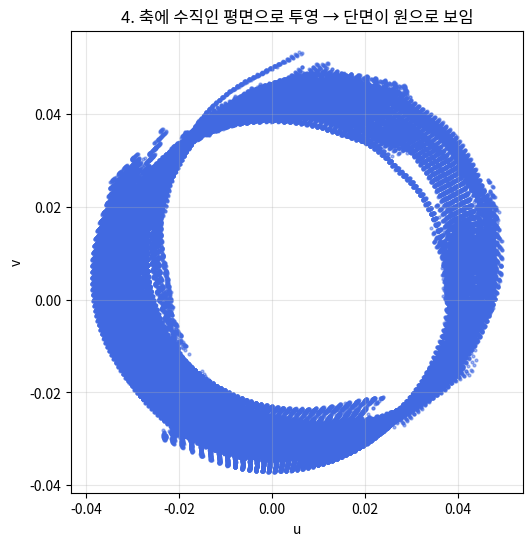

In [9]:
ref_vec = np.array([1,0,0]) if abs(axis_dir[0]) < 0.9 else np.array([0,1,0])
u = np.cross(axis_dir, ref_vec); u /= np.linalg.norm(u)
v = np.cross(axis_dir, u)

pts_centered = points - mean_pts
pts_2d = np.stack([pts_centered @ u, pts_centered @ v], axis=1)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(pts_2d[:,0], pts_2d[:,1], s=4, c='royalblue', alpha=0.5)
ax.set_aspect('equal'); ax.grid(alpha=0.3)
ax.set_title('4. 축에 수직인 평면으로 투영 → 단면이 원으로 보임')
ax.set_xlabel('u'); ax.set_ylabel('v'); plt.show()

## 5. RANSAC 2D 원 피팅

```python
for _ in range(500):
    무작위 3점 선택 → 세 점을 지나는 원의 중심·반지름 계산
    원에서 INLIER_THRESH 이내인 점(inlier) 개수 세기
    인라이어가 가장 많은 원을 채택
```

세 점이 주어지면 원이 유일하게 결정됩니다. 무작위로 3점을 뽑아 원을 만들고, 그 원에 잘 맞는 점이 가장 많은 후보를 고르는 방식(RANSAC)으로 **노이즈·이상치에 강건하게** 원을 찾습니다.

3점 원 방정식: $2x_c x + 2y_c y + (r^2 - x_c^2 - y_c^2) = x^2 + y^2$ 를 선형계로 풀어 중심 $(x_c, y_c)$ 와 반지름 $r$ 을 구합니다.

검출 반지름 = 0.0379 (실제 0.1)
인라이어 = 147478 / 165263


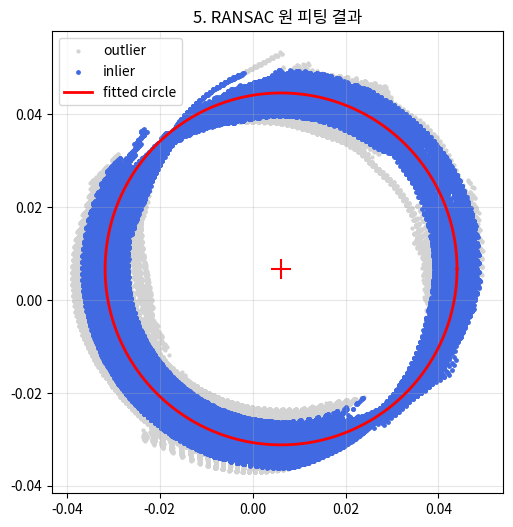

In [10]:
best_r, best_center_2d, max_inliers = 0, np.array([0,0]), 0
best_inlier_mask = None

for _ in range(N_ITER):
    if len(pts_2d) < 3:
        break
    p1, p2, p3 = pts_2d[np.random.choice(len(pts_2d), 3, replace=False)]
    A = np.array([[2*p1[0], 2*p1[1], 1],
                  [2*p2[0], 2*p2[1], 1],
                  [2*p3[0], 2*p3[1], 1]])
    b = np.array([p1@p1, p2@p2, p3@p3])
    try:
        sol = np.linalg.solve(A, b)
    except np.linalg.LinAlgError:
        continue
    xc, yc = sol[0], sol[1]
    r = np.sqrt(max(0, sol[2] + xc**2 + yc**2))
    dists = np.abs(np.sqrt((pts_2d[:,0]-xc)**2 + (pts_2d[:,1]-yc)**2) - r)
    mask = dists < INLIER_THRESH
    if mask.sum() > max_inliers:
        max_inliers = mask.sum()
        best_r, best_center_2d, best_inlier_mask = r, np.array([xc, yc]), mask

print(f'검출 반지름 = {best_r:.4f} (실제 {RADIUS_TRUE})')
print(f'인라이어 = {max_inliers} / {len(pts_2d)}')

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(pts_2d[~best_inlier_mask,0], pts_2d[~best_inlier_mask,1], s=4, c='lightgray', label='outlier')
ax.scatter(pts_2d[best_inlier_mask,0], pts_2d[best_inlier_mask,1], s=6, c='royalblue', label='inlier')
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(best_center_2d[0]+best_r*np.cos(theta), best_center_2d[1]+best_r*np.sin(theta),
        'r-', lw=2, label='fitted circle')
ax.scatter(*best_center_2d, c='red', marker='+', s=200)
ax.set_aspect('equal'); ax.grid(alpha=0.3); ax.legend()
ax.set_title('5. RANSAC 원 피팅 결과'); plt.show()

## 6. 2D → 3D 복원 및 최종 결과

```python
axis_origin = mean_pts + best_center_2d[0]*u + best_center_2d[1]*v
return {origin, direction: axis_dir, radius: best_r}
```

2D 평면에서 찾은 원 중심을 다시 3D로 되돌리면 **원기둥 축이 지나는 한 점(origin)** 이 됩니다. 축 방향 `axis_dir`, 반지름 `best_r`과 함께 원기둥이 완전히 정의됩니다.

In [ ]:
axis_origin = mean_pts + best_center_2d[0]*u + best_center_2d[1]*v
result = {'origin': axis_origin, 'direction': axis_dir, 'radius': best_r}
print('검출 결과')
print('  origin   :', np.round(result['origin'], 4))
print('  direction:', np.round(result['direction'], 4))
print('  radius   :', round(result['radius'], 4))

# 검출 원기둥의 길이: 이웃 점들을 축에 투영한 범위로 자동 계산 (합성/실제 모두 대응)
axis_proj = (points - axis_origin) @ axis_dir
height = axis_proj.max() - axis_proj.min()
# 원기둥 중심을 축 투영 범위의 가운데로 보정
center = axis_origin + axis_dir * (axis_proj.max() + axis_proj.min()) / 2

# open3d: 전체 점(회색) + 검출 원기둥(초록) + 축(초록 선) + 입력점(빨강)
show3d([
    make_pcd(_ds(all_pts), 'gray'),
    make_cylinder(center, axis_dir, best_r, height, 'green'),
    make_lines(center - axis_dir*height*0.6, center + axis_dir*height*0.6, 'green'),
    make_marker(input_point, 'red', MARKER_R),
])
print('6. 최종 검출된 원기둥 (초록) — 마우스로 돌려서 점군과 겹치는지 확인')

## 요약

| 단계 | 핵심 연산 | 의미 |
|------|-----------|------|
| 1 | `KDTreeFlann.search_radius_vector_3d` | 입력점 주변 국소 영역만 추출 |
| 2 | `estimate_normals` | 표면 법선 (축에 수직) 추정 |
| 3 | `np.cov` + `eigh` | **법선 공분산 최소 고유벡터 = 축** |
| 4 | `u, v` 투영 | 3D 단면 → 2D 원 |
| 5 | RANSAC 원 피팅 | 노이즈에 강건한 중심·반지름 |
| 6 | 2D→3D 역변환 | origin / direction / radius 복원 |

**한 줄 요약:** 원기둥 표면 법선이 축에 수직이라는 성질을 이용해 축을 찾고, 그 축에 수직인 평면에 점을 펼쳐 원을 RANSAC으로 피팅하는 알고리즘입니다.

> 원본 `fit_cylinder()`는 위 1~6단계를 한 함수에 담은 것입니다. 실제 PCD에 적용하려면 `create_test_cylinder()` 대신 `o3d.io.read_point_cloud('your.pcd')`로 불러오고, `input_point`를 검출하려는 파이프 근처 좌표로 바꾸면 됩니다.